In [778]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [779]:
df = pd.read_csv('PEA04.20231018T191000.csv')
df.head()

,STATISTIC Label,Year,Age Group,Sex,Region,UNIT,VALUE
0,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,State,Thousand,356.0
1,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Border,Thousand,30.7
2,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,West,Thousand,32.6
3,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Mid-West,Thousand,35.0
4,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,South-East,Thousand,32.0


In [780]:
df.index

RangeIndex(start=0, stop=6669, step=1)

In [781]:
df.isna().sum()

STATISTIC Label    0
Year               0
Age Group          0
Sex                0
Region             0
UNIT               0
VALUE              0
dtype: int64

In [782]:
# df[['year', 'value']]

In [783]:
df.describe()

,Year,VALUE
count,6669.000000,6669.000000
mean,2017.000000,75.670460
std,3.741938,281.512172
min,2011.000000,1.200000
25%,2014.000000,12.500000
50%,2017.000000,20.700000
75%,2020.000000,42.200000
max,2023.000000,5281.600000


In [784]:
df.columns

Index(['STATISTIC Label', 'Year', 'Age Group', 'Sex', 'Region', 'UNIT',
       'VALUE'],
      dtype='object')

In [785]:

# changing the columns name to make it easy to understand.
# inplace = True set the valuses parmently so that we can use the new columns names
df.rename(columns={'STATISTIC Label': 'statistic_label', 'Year': 'year', 'Age Group':'age_group', 'Sex':'sex', 'Region':'region', 'UNIT':'unit','VALUE':'value'},inplace=True)

In [786]:
df.head()

,statistic_label,year,age_group,sex,region,unit,value
0,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,State,Thousand,356.0
1,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Border,Thousand,30.7
2,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,West,Thousand,32.6
3,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Mid-West,Thousand,35.0
4,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,South-East,Thousand,32.0


In [787]:
#now drop tha table one that is "statistic_label" because there is no any usefull data only text is reperting throught the table  so eliminate it
df.drop({'statistic_label', 'unit'}, axis=1, inplace=True)

In [788]:
## and the valuse are in thousand to we multiply the values column in thousand
df['value'] = df['value']

In [789]:
years = df['year'].unique()
years
#2011	0 - 4 years	Male	State

array([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023])

In [790]:
# filt1 = (df['age_group'] == '0 - 4 years') & (df['sex'] == 'Both sexes') & (df['region'] == 'State')
filt_border = df.loc[(df['sex'] == 'Both sexes') & (df['region'] == 'Border') & (df['age_group'] == 'All ages')]
filt_west = df.loc[(df['sex'] == 'Both sexes') & (df['region'] == 'West') & (df['age_group'] == 'All ages')]
filt_mwest = df.loc[(df['sex'] == 'Both sexes') & (df['region'] == 'Mid-West') & (df['age_group'] == 'All ages')]
filt_seast = df.loc[(df['sex'] == 'Both sexes') & (df['region'] == 'South-East') & (df['age_group'] == 'All ages')]
filt_swest = df.loc[(df['sex'] == 'Both sexes') & (df['region'] == 'South-West') & (df['age_group'] == 'All ages')]
filt_dublin = df.loc[(df['sex'] == 'Both sexes') & (df['region'] == 'Dublin') & (df['age_group'] == 'All ages')]
filt_meast = df.loc[(df['sex'] == 'Both sexes') & (df['region'] == 'Mid-East') & (df['age_group'] == 'All ages')]
filt_mland = df.loc[(df['sex'] == 'Both sexes') & (df['region'] == 'Midland') & (df['age_group'] == 'All ages')]
border_value = filt_border[['year', 'value', 'region']].reset_index(drop=True)
west_value = filt_west[['year', 'value', 'region']].reset_index(drop=True)
mwest_value = filt_mwest[['year', 'value', 'region']].reset_index(drop=True)
seast_value = filt_seast[['year', 'value', 'region']].reset_index(drop=True)
swest_value = filt_swest[['year', 'value', 'region']].reset_index(drop=True)
dublin_value = filt_dublin[['year', 'value', 'region']].reset_index(drop=True)
meast_value = filt_meast[['year', 'value', 'region']].reset_index(drop=True)
mland_value = filt_mland[['year', 'value', 'region']].reset_index(drop=True)
df['region'].unique()
border_value

,year,value,region
0,2011,391.9,Border
1,2012,392.1,Border
2,2013,393.1,Border
3,2014,392.0,Border
4,2015,391.9,Border
5,2016,393.3,Border
6,2017,400.3,Border
7,2018,405.7,Border
8,2019,409.9,Border
9,2020,412.0,Border


In [791]:
# total_pop = np.array({'west':west_value,'m-west':mwest_value,'s-east':seast_value,'s-west':swest_value,'s-dublin':dublin_value,'m-east':meast_value,'m-land':mland_value})
#
# total_pop = pd.Series(data = total_pop)
# total_pop = pd.DataFrame(total_pop)
# total_pop

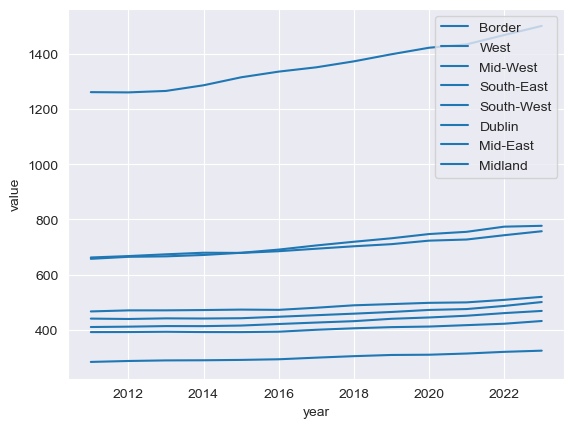

In [792]:
# region = ['Border', 'West', 'Mid-West', 'South-East', 'South-West','Dublin', 'Mid-East', 'Midland']
years = df['year'].unique()
sns.lineplot(y= 'value', x='year', data =border_value, hue ='region')
sns.lineplot(y= 'value', x='year', data =west_value, hue ='region')
sns.lineplot(y= 'value', x='year', data =mwest_value, hue ='region')
sns.lineplot(y= 'value', x='year', data =seast_value,hue ='region')
sns.lineplot(y= 'value', x='year', data =swest_value,hue ='region' )
sns.lineplot(y= 'value', x='year', data =dublin_value,hue ='region')
sns.lineplot(y= 'value', x='year', data =meast_value, hue ='region')
sns.lineplot(y= 'value', x='year', data =mland_value,hue ='region')
plt.legend()

In [793]:
west_value[['value']]

,value
0,440.8
1,439.4
2,441.7
3,441.1
4,442.2
5,447.5
6,453.1
7,458.7
8,464.8
9,472.2


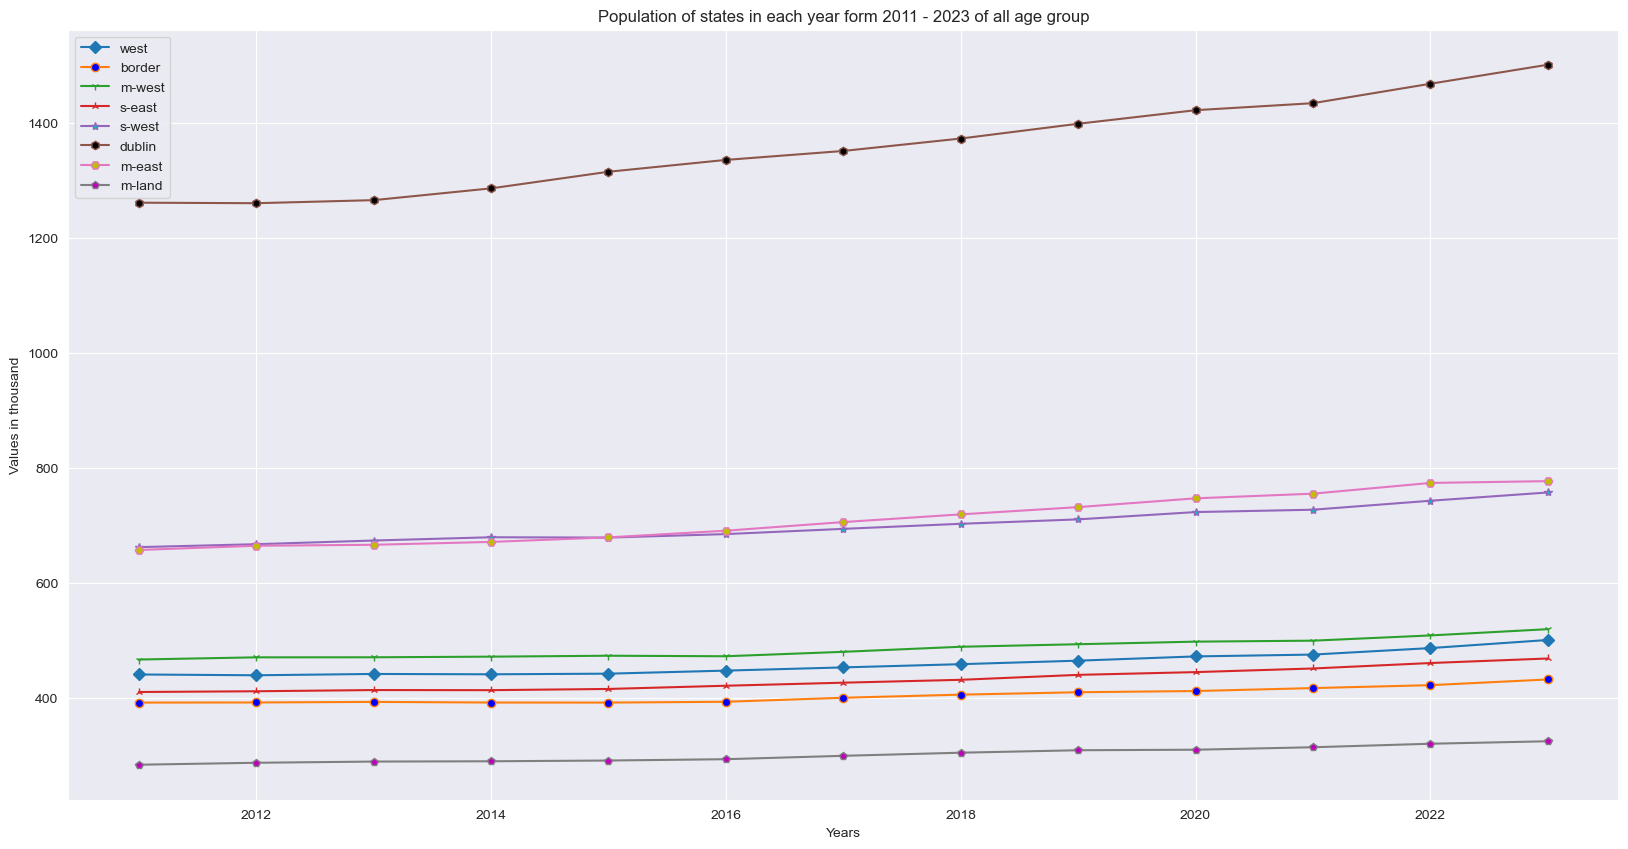

In [794]:
fig, BarGraph = plt.subplots(figsize=(20, 10), )
bar_colors = ['#CD5555','#CD5777','#CD3455','#CD8977', '#FF00FF', '#EE30A7', '#B452CD', '#F5FFFA','#EEB4B4', '#436EEE', '#FA8072', '#3A5FCD', '#FF8072']
BarGraph.plot(years, west_value[['value']], label='west', marker='D')
BarGraph.plot(years, border_value[['value']], label='border', marker='o', mfc='b')
BarGraph.plot(years, mwest_value[['value']], label='m-west', marker='1', mfc='g')
BarGraph.plot(years, seast_value[['value']], label='s-east', marker='2', mfc='r')
BarGraph.plot(years, swest_value[['value']], label='s-west', marker='*', mfc='c')
BarGraph.plot(years, dublin_value[['value']], label='dublin', marker='h', mfc='k')
BarGraph.plot(years, meast_value[['value']], label='m-east', marker='H', mfc='y')
BarGraph.plot(years, mland_value[['value']], label='m-land', marker='p', mfc='m')
plt.xlabel('Years')
plt.ylabel('Values in thousand')
plt.title("Population of states in each year form 2011 - 2023 of all age group")
plt.legend()
plt.show()

In [802]:
 # we can see that there is slightly decrease in population for 2011 to 2023 which indicate that the birth rate has decresed by
#now calculate the change
dublin_value

,year,value,region
0,2011,1261.5,Dublin
1,2012,1260.6,Dublin
2,2013,1265.9,Dublin
3,2014,1286.4,Dublin
4,2015,1315.3,Dublin
5,2016,1335.9,Dublin
6,2017,1351.5,Dublin
7,2018,1373.1,Dublin
8,2019,1398.8,Dublin
9,2020,1422.4,Dublin


In [796]:
every_year_decreased = -17.47191 / 12
every_year_decreased
# about 1.4559925 % the birth rate is decreasing every year

-1.4559925

In [797]:
state_filt = (df['sex'] == 'Both sexes') & (df['region'] == 'State') & (df['age_group'] == 'All ages')
state_pop = df.loc[state_filt]

In [798]:
state_pop.dtypes

year           int64
age_group     object
sex           object
region        object
value        float64
dtype: object

In [799]:
state_pop['year'].astype('int32')

486     2011
999     2012
1512    2013
2025    2014
2538    2015
3051    2016
3564    2017
4077    2018
4590    2019
5103    2020
5616    2021
6129    2022
6642    2023
Name: year, dtype: int32

Text(0.5, 1.0, 'Population in States form 2011 - 2023 of All ages group')

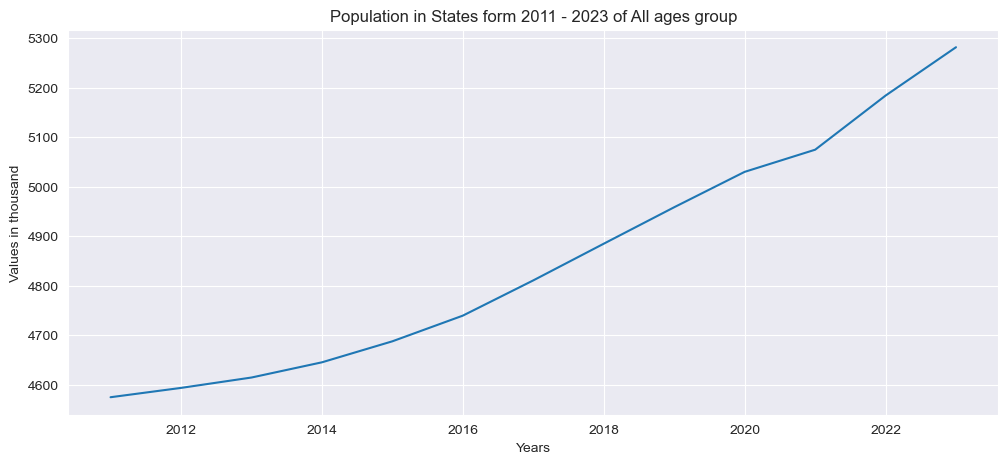

In [800]:
#total population in each year form 2011 to 2023
year = pd.to_datetime(state_pop['year'], format= '%Y')
values = state_pop['value']
fig, BarGraph = plt.subplots(figsize=(12, 5))
bar_colors = ['#CD5555','#CD5777','#CD3455','#CD8977', '#FF00FF', '#EE30A7', '#B452CD', '#F5FFFA','#EEB4B4', '#436EEE', '#FA8072', '#3A5FCD', '#FF8072']
BarGraph.plot(year, values, )
# BarGraph.bar(pop_2011['year'], pop_2011['value']/1000, color = bar_colors)
plt.xlabel('Years')
plt.ylabel('Values in thousand')
plt.title("Population in States form 2011 - 2023 of All ages group")
# plt.show()

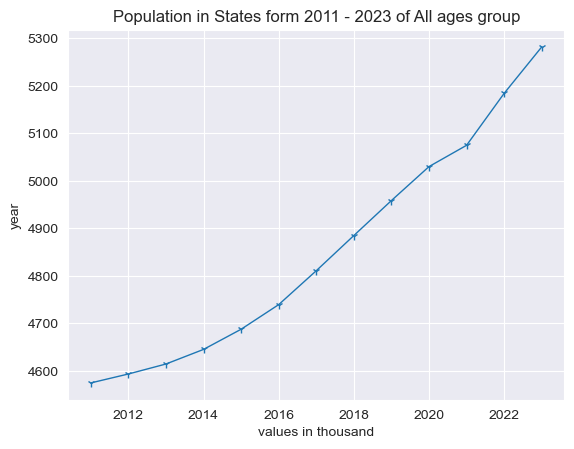

In [801]:
plt.plot(state_pop['year'], state_pop['value'], marker='1', label='All age', linewidth = 1)
plt.xlabel('values in thousand')
plt.ylabel('year')
plt.title("Population in States form 2011 - 2023 of All ages group")
plt.show()